<a href="https://colab.research.google.com/github/austin-codd/Bihar-Labour-Force-Cluster-Analysis/blob/main/Summer_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install prince -q

import pandas as pd
import numpy as np
import prince
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 3.2 MB/s eta 0:00:00


In [ ]:
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_excel('PLFS_Bihar.xlsx')



In [ ]:
features = ['ERN_MNTH', 'GEDU_LVL', 'PAS', 'IND_PAS', 'OCU_PAS']
df_selected = df[features].copy()

In [ ]:
activity_codes = [11, 12, 21, 31, 41, 51]
df_labor = df_selected[df_selected['PAS'].isin(activity_codes)].copy()

In [ ]:

def group_education(gedu_code):
    if gedu_code <= 5: return 'Primary_or_Below'
    if 6 <= gedu_code <= 10: return 'Middle_to_Secondary'
    if gedu_code >= 11: return 'Higher_Education'
    else:
      return 'Unknown'

def group_industry(nic_code):
    if pd.isna(nic_code): return 'Not_Applicable'
    nic_str = str(int(nic_code))
    if nic_str.startswith(('1', '2', '3')): return 'Agriculture'
    if nic_str.startswith(('5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27','28','29','30','31','32','33')): return 'Manufacturing_&_Mining'
    if nic_str.startswith == '41': return 'Construction'
    if nic_str.startswith(('45', '46', '47')): return 'Trade_&_Retail'
    if nic_str.startswith(('49', '50', '51','52','53','54','55','56')): return 'Transport_&_Services'
    if nic_str.startswith == 84: return 'Public_Admin'
    if nic_str.startswith == 85: return 'Education'
    if nic_str.startswith(('86', '87', '88')): return 'Health_&_SocialWork'
    else:
      return 'Other_Services'

def group_occupation(nco_code):
    if pd.isna(nco_code): return 'Not_Applicable'
    nco_str = str(int(nco_code))
    if nco_str.startswith(('1', '2', '3')): return 'High_Skill_Professional'
    if nco_str.startswith(('4', '5')): return 'Medium_Skill_Clerical_Sales'
    if nco_str.startswith(('6', '7', '8')): return 'Skilled_Trades_&_Agriculture'
    if nco_str.startswith('9'): return 'Elementary_Occupations'
    else:
      return 'Other'


def group_status(pas_code):
    if pas_code in [11, 12, 21]: return 'Self_Employed'
    if pas_code == 31: return 'Salaried_Regular'
    if pas_code in [41, 51]: return 'Casual_Labour'
    if pas_code == 81: return 'Unemployed'
    else:
      return 'Other'

df_labor['EDU_GROUP'] = df_labor['GEDU_LVL'].apply(group_education)
df_labor['IND_GROUP'] = df_labor['IND_PAS'].apply(group_industry)
df_labor['OCU_GROUP'] = df_labor['OCU_PAS'].apply(group_occupation)
df_labor['STATUS_GROUP'] = df_labor['PAS'].apply(group_status)


In [ ]:
df_labor['IND_GROUP'].value_counts()

,count
IND_GROUP,
Agriculture,2763
Other_Services,1235
Trade_&_Retail,1018
Manufacturing_&_Mining,868
Transport_&_Services,330


In [ ]:
numerical_features = ['ERN_MNTH']
categorical_features = ['EDU_GROUP', 'IND_GROUP', 'OCU_GROUP', 'STATUS_GROUP']

df_processed = df_labor[numerical_features + categorical_features].copy()
df_processed['ERN_MNTH'] = df_processed['ERN_MNTH'].fillna(0)
df_processed.dropna(inplace=True)





In [ ]:
df_encoded = pd.get_dummies(df_processed, columns=categorical_features, drop_first=True)

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

In [ ]:
df_encoded.shape

(6214, 12)

## PERFORMING MCA

In [ ]:
categorical_features_for_mca = ['EDU_GROUP', 'IND_GROUP', 'OCU_GROUP', 'STATUS_GROUP']
df_mca_input = df_labor[categorical_features_for_mca].astype(str)

In [ ]:
mca_explorer = prince.MCA(n_components=10, n_iter=3, random_state=42)
mca_explorer = mca_explorer.fit(df_mca_input)
eigenvalues = mca_explorer.eigenvalues_
explained_inertia_ratio = [(eig / sum(eigenvalues)) for eig in eigenvalues]
cumulative_inertia = np.cumsum(explained_inertia_ratio)

In [ ]:
optimal_n_components = np.argmax(cumulative_inertia >= 0.80) + 1
print(f"Optimal number of components to retain ~80% inertia: {optimal_n_components}")

Optimal number of components to retain ~80% inertia: 5


In [ ]:
mca = prince.MCA(n_components=optimal_n_components, n_iter=3, random_state=42)
df_mca = mca.fit_transform(df_mca_input)

# Scaling the numeric variable

In [ ]:
numerical_features = df_labor[['ERN_MNTH']].fillna(0)
df_to_cluster = pd.concat([numerical_features.reset_index(drop=True), df_mca.reset_index(drop=True)], axis=1)
df_to_cluster.columns = df_to_cluster.columns.astype(str)

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_to_cluster)

# Training the k-means model

* Finding the optimal value for k

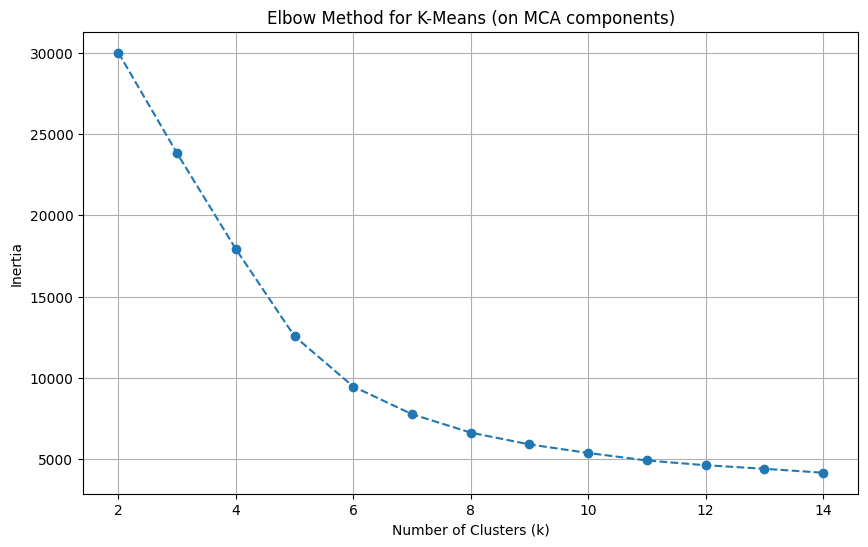

In [ ]:
inertias = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 15), inertias, marker='o', linestyle='--')
plt.title('Elbow Method for K-Means (on MCA components)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

* the graph levels off after 7

# Model eval

In [ ]:
from sklearn.metrics import calinski_harabasz_score,davies_bouldin_score

In [ ]:
optimal_k = 7 # Based on the elbow plot
kmeans_final = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
clusters = kmeans_final.fit_predict(df_scaled)

In [ ]:
score = silhouette_score(df_scaled, clusters)
ch_score = calinski_harabasz_score(df_scaled, clusters)
db_score = davies_bouldin_score(df_scaled, clusters)
print(f"\nSilhouette Score for k={optimal_k}: {score:.3f}")
print(f"Calinski-Harabasz Score: {ch_score}")
print(f"Davies-Bouldin Score: {db_score}")


Silhouette Score for k=7: 0.549
Calinski-Harabasz Score: 3928.746131510509
Davies-Bouldin Score: 0.6690014149468231


# Using Dimensionality Reduction to visualise the clusters

In [ ]:
# PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

In [ ]:
df_pca[:,0]

array([ 1.20868   ,  0.37496549,  0.31083361, ...,  0.24254544,
       -1.88963303,  0.24254544])

In [ ]:
import seaborn as sns

<Axes: >

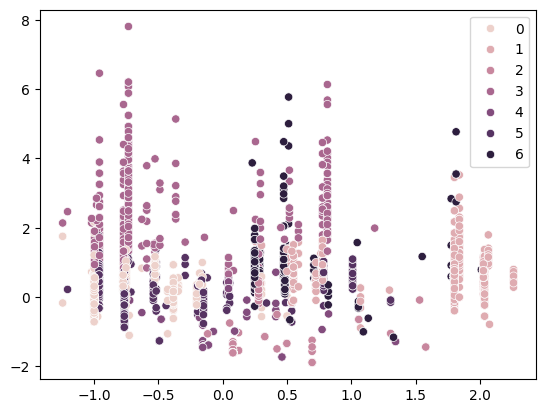

In [ ]:
sns.scatterplot(y=df_pca[:,0], x=df_pca[:,1], hue=clusters,alpha=1)

* there is significant overlap in the clusters which is normal as the data pertains to humans who have the tendancy to misreport

# Profiling of the Clusters

In [ ]:
df_processed['Cluster'] = clusters

print("\n--- Detailed Cluster Profiles ---")
summary = df_processed.groupby('Cluster').agg(
    Count=('Cluster', 'size'),
    Avg_Earnings=('ERN_MNTH', 'mean'),
    Mode_Status=('STATUS_GROUP', lambda x: x.mode().iloc[0]),
    Mode_Industry=('IND_GROUP', lambda x: x.mode().iloc[0]),
    Mode_Occupation=('OCU_GROUP', lambda x: x.mode().iloc[0]),
    Mode_Education=('EDU_GROUP', lambda x: x.mode().iloc[0]),
).round(1)

print(summary)
print("\n--- End of K-Means with MCA Analysis ---")


--- Detailed Cluster Profiles ---
         Count  Avg_Earnings       Mode_Status           Mode_Industry  \
Cluster                                                                  
0         1667       11143.7     Self_Employed             Agriculture   
1         1127       14426.9     Self_Employed          Trade_&_Retail   
2          558         453.8     Casual_Labour          Other_Services   
3          544       28342.9  Salaried_Regular  Manufacturing_&_Mining   
4          839         307.2     Casual_Labour          Other_Services   
5         1149        9071.5     Self_Employed             Agriculture   
6          330       15951.2     Self_Employed    Transport_&_Services   

                      Mode_Occupation       Mode_Education  
Cluster                                                     
0        Skilled_Trades_&_Agriculture  Middle_to_Secondary  
1         Medium_Skill_Clerical_Sales  Middle_to_Secondary  
2              Elementary_Occupations     Primary_or_B

In [ ]:
summary

,Count,Avg_Earnings,Mode_Status,Mode_Industry,Mode_Occupation,Mode_Education
Cluster,,,,,,
0,1667,11143.7,Self_Employed,Agriculture,Skilled_Trades_&_Agriculture,Middle_to_Secondary
1,1127,14426.9,Self_Employed,Trade_&_Retail,Medium_Skill_Clerical_Sales,Middle_to_Secondary
2,558,453.8,Casual_Labour,Other_Services,Elementary_Occupations,Primary_or_Below
3,544,28342.9,Salaried_Regular,Manufacturing_&_Mining,High_Skill_Professional,Higher_Education
4,839,307.2,Casual_Labour,Other_Services,Elementary_Occupations,Middle_to_Secondary
5,1149,9071.5,Self_Employed,Agriculture,Skilled_Trades_&_Agriculture,Primary_or_Below
6,330,15951.2,Self_Employed,Transport_&_Services,Skilled_Trades_&_Agriculture,Middle_to_Secondary


# Writting to Excel

In [ ]:
df_processed

,ERN_MNTH,EDU_GROUP,IND_GROUP,OCU_GROUP,STATUS_GROUP,Cluster
0,30000,Middle_to_Secondary,Agriculture,Skilled_Trades_&_Agriculture,Self_Employed,0
1,17000,Middle_to_Secondary,Agriculture,Skilled_Trades_&_Agriculture,Self_Employed,0
2,16000,Middle_to_Secondary,Agriculture,Skilled_Trades_&_Agriculture,Self_Employed,0
3,24000,Middle_to_Secondary,Agriculture,Skilled_Trades_&_Agriculture,Self_Employed,0
5,0,Primary_or_Below,Other_Services,Elementary_Occupations,Casual_Labour,2
...,...,...,...,...,...,...
6548,30000,Higher_Education,Manufacturing_&_Mining,High_Skill_Professional,Salaried_Regular,3
6549,0,Middle_to_Secondary,Other_Services,Elementary_Occupations,Casual_Labour,4
6550,7000,Middle_to_Secondary,Manufacturing_&_Mining,Elementary_Occupations,Salaried_Regular,4
6551,0,Primary_or_Below,Other_Services,Elementary_Occupations,Casual_Labour,2


In [ ]:
df_processed.to_excel('PLFS_Processed.xlsx',index=False)